In [3]:
# Cell 1: Title & Description (Text Cell)
"""
# Project 2: Transformer-Based Sentiment Analysis (DistilBERT fine-tuned on IMDb)

## Objective
Fine-tune a lightweight **DistilBERT** transformer model for binary sentiment classification on the IMDb movie review dataset.

## Tools Used
- **Transformers** (Hugging Face) – DistilBERT tokenizer & model
- **PyTorch** – Deep learning framework
- **Datasets** – Efficient data handling
- **scikit-learn** – Metrics & baseline comparison
- **Matplotlib / Seaborn** – Visualizations

## Dataset Info
- **Source**: IMDb movie reviews (50,000 labeled reviews)
- **Classes**: Positive (1) / Negative (0)
- **Sampling**: 10,000 stratified samples for memory efficiency
- **Split**: 80% train, 20% test

## Key Features
- GPU-accelerated fine-tuning on Google Colab free tier
- Memory-optimized with DistilBERT (6 layers vs BERT's 12)
- Complete evaluation with precision, recall, F1, confusion matrix
- Model comparison with classical ML baseline
"""

"\n# Project 2: Transformer-Based Sentiment Analysis (DistilBERT fine-tuned on IMDb)\n\n## Objective\nFine-tune a lightweight **DistilBERT** transformer model for binary sentiment classification on the IMDb movie review dataset.\n\n## Tools Used\n- **Transformers** (Hugging Face) – DistilBERT tokenizer & model\n- **PyTorch** – Deep learning framework\n- **Datasets** – Efficient data handling\n- **scikit-learn** – Metrics & baseline comparison\n- **Matplotlib / Seaborn** – Visualizations\n\n## Dataset Info\n- **Source**: IMDb movie reviews (50,000 labeled reviews)\n- **Classes**: Positive (1) / Negative (0)\n- **Sampling**: 10,000 stratified samples for memory efficiency\n- **Split**: 80% train, 20% test\n\n## Key Features\n- GPU-accelerated fine-tuning on Google Colab free tier\n- Memory-optimized with DistilBERT (6 layers vs BERT's 12)\n- Complete evaluation with precision, recall, F1, confusion matrix\n- Model comparison with classical ML baseline\n"

In [4]:
# Cell 2: Install Dependencies
!pip install transformers datasets torch scikit-learn matplotlib seaborn pandas -q

In [5]:
# Cell 3: Import All Libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import pandas as pd
import numpy as np
import random
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {__import__('transformers').__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu128
Transformers version: 5.0.0
CUDA available: True


In [6]:
# Cell 4: Load & Preprocess Dataset
try:
    # Load dataset from Google Drive (already mounted manually)
    df = pd.read_csv('/content/drive/MyDrive/DATASETS_For the data analysis/IMDB Dataset.csv')
    print(f"Original dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    # Map sentiment: positive -> 1, negative -> 0
    df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

    # Drop nulls if any
    df = df.dropna(subset=['review', 'sentiment'])

    # Sample 10,000 rows stratified
    df_sampled, _ = train_test_split(
        df,
        train_size=10000,
        stratify=df['label'],
        random_state=42
    )
    print(f"\nSampled dataset shape: {df_sampled.shape}")

    # Print class distribution
    class_counts = df_sampled['label'].value_counts()
    print("\nClass distribution after sampling:")
    print(f"Positive (1): {class_counts[1]} ({class_counts[1]/len(df_sampled)*100:.1f}%)")
    print(f"Negative (0): {class_counts[0]} ({class_counts[0]/len(df_sampled)*100:.1f}%)")

except FileNotFoundError:
    print("ERROR: 'IMDB_Dataset.csv' not found in your Google Drive root folder.")
    print("Please make sure the file is in My Drive (root, not inside any subfolder).")
    raise

Original dataset shape: (50000, 2)
Columns: ['review', 'sentiment']

Sampled dataset shape: (10000, 3)

Class distribution after sampling:
Positive (1): 5000 (50.0%)
Negative (0): 5000 (50.0%)


/tmp/ipykernel_1210/4053262783.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Negative (0)', 'Positive (1)'])


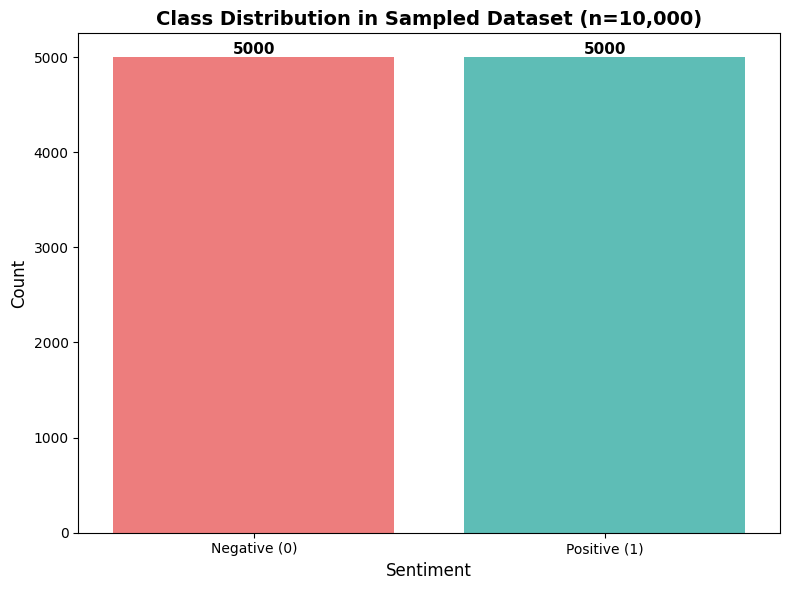

✓ Diagram saved: class_distribution.png


In [7]:
# Cell 5: DIAGRAM 1 - Class Distribution Bar Chart
plt.figure(figsize=(8, 6))
colors = ['#ff6b6b', '#4ecdc4']
ax = sns.countplot(data=df_sampled, x='label', hue='label', palette=colors, legend=False)
ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
plt.title('Class Distribution in Sampled Dataset (n=10,000)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value labels on bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Diagram saved: class_distribution.png")

In [8]:
# Cell 6: Train/Test split
X = df_sampled['review'].values
y = df_sampled['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set size: {len(X_train)} ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({(len(X_test)/len(X))*100:.1f}%)")
print(f"\nTrain class distribution - Positive: {np.sum(y_train)}, Negative: {len(y_train)-np.sum(y_train)}")
print(f"Test class distribution - Positive: {np.sum(y_test)}, Negative: {len(y_test)-np.sum(y_test)}")

Training set size: 8000 (80.0%)
Test set size: 2000 (20.0%)

Train class distribution - Positive: 4000, Negative: 4000
Test class distribution - Positive: 1000, Negative: 1000


In [9]:
# Cell 7: Tokenization
# Load DistilBert tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
print(f"Tokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Max model length: {tokenizer.model_max_length}")

def tokenize_data(texts, max_length=128):
    """Tokenize texts with padding and truncation"""
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

# Tokenize train and test sets
print("\nTokenizing training set...")
train_encodings = tokenize_data(X_train)
print(f"Train encodings - input_ids shape: {train_encodings['input_ids'].shape}")
print(f"Train encodings - attention_mask shape: {train_encodings['attention_mask'].shape}")

print("\nTokenizing test set...")
test_encodings = tokenize_data(X_test)
print(f"Test encodings - input_ids shape: {test_encodings['input_ids'].shape}")

# Sample output
print("\nSample token IDs (first review, first 20 tokens):")
print(train_encodings['input_ids'][0][:20])
print("\nSample attention mask (first review, first 20 tokens):")
print(train_encodings['attention_mask'][0][:20])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: DistilBertTokenizer
Vocab size: 30522
Max model length: 512

Tokenizing training set...
Train encodings - input_ids shape: torch.Size([8000, 128])
Train encodings - attention_mask shape: torch.Size([8000, 128])

Tokenizing test set...
Test encodings - input_ids shape: torch.Size([2000, 128])

Sample token IDs (first review, first 20 tokens):
tensor([  101,  2023,  2143,  2003,  2242,  2066,  1037,  8297,  1997,  1000,
         2317, 11798,  1000,  1010,  2144,  2009,  2003,  2081,  2011,  1996])

Sample attention mask (first review, first 20 tokens):
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [10]:
# Cell 8: PyTorch Dataset class
class IMDbDataset(Dataset):
    """PyTorch Dataset for IMDb reviews"""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

    def __len__(self):
        return len(self.labels)

# Create dataset instances
train_dataset = IMDbDataset(train_encodings, y_train)
test_dataset = IMDbDataset(test_encodings, y_test)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"\nSample from dataset: {train_dataset[0]['input_ids'].shape}, label: {train_dataset[0]['labels']}")

Train dataset size: 8000
Test dataset size: 2000

Sample from dataset: torch.Size([128]), label: 0


In [11]:
# Cell 9: DataLoaders
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0  # Colab compatibility
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")

Train batches: 500
Test batches: 125
Batch size: 16


In [12]:
# Cell 10: Load DistilBERT model
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

try:
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2,
        torch_dtype=torch.float32
    )
    model = model.to(device)
    print(f"\n✓ Model loaded: {model.__class__.__name__}")
    print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"Model device: {next(model.parameters()).device}")

except Exception as e:
    print(f"Error loading model: {e}")
    raise

Using device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Model loaded: DistilBertForSequenceClassification
Number of parameters: 66,955,010
Trainable parameters: 66,955,010
Model device: cuda:0


/tmp/ipykernel_1210/3578962809.py:33: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1210/3578962809.py:33: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1210/3578962809.py:33: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1210/3578962809.py:33: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1210/3578962809.py:34: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.savefig('distilbert_pipeline.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1210/3578962809.py:34: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.savefig('distilbert_pipeline.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1210/3578962809.py:34: UserWarning: Glyph 1295

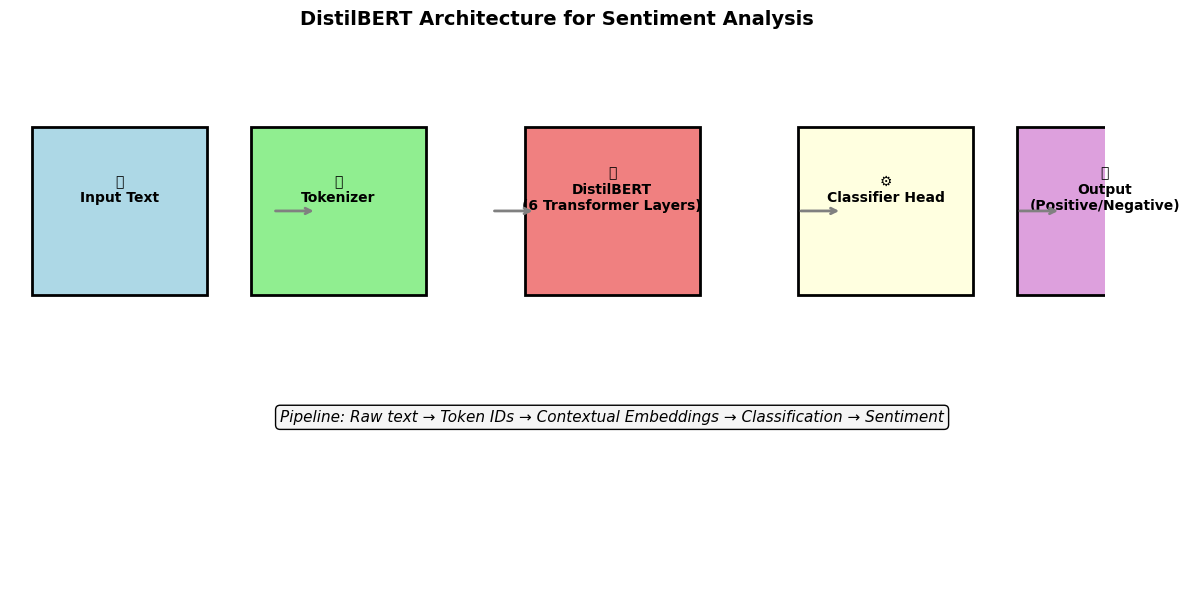

✓ Diagram saved: distilbert_pipeline.png


In [13]:
# Cell 11: DIAGRAM 2 - DistilBERT Architecture Overview
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')

# Define boxes and their positions
boxes = [
    ("Input Text", (1, 3.5), "lightblue", "📝"),
    ("Tokenizer", (3, 3.5), "lightgreen", "🔤"),
    ("DistilBERT\n(6 Transformer Layers)", (5.5, 3.5), "lightcoral", "🧠"),
    ("Classifier Head", (8, 3.5), "lightyellow", "⚙️"),
    ("Output\n(Positive/Negative)", (10, 3.5), "plum", "🎯")
]

# Draw boxes
for label, (x, y), color, emoji in boxes:
    rect = plt.Rectangle((x-0.8, y-0.8), 1.6, 1.6, facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y+0.2, f"{emoji}\n{label}", ha='center', va='center', fontsize=10, fontweight='bold')

# Draw arrows
arrows = [(2.4, 3.5, 2.8, 3.5), (4.4, 3.5, 4.8, 3.5), (7.2, 3.5, 7.6, 3.5), (9.2, 3.5, 9.6, 3.5)]
for x1, y1, x2, y2 in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))

# Add description text
ax.text(5.5, 1.5, "Pipeline: Raw text → Token IDs → Contextual Embeddings → Classification → Sentiment",
        ha='center', fontsize=11, style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="whitesmoke"))

plt.title("DistilBERT Architecture for Sentiment Analysis", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('distilbert_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Diagram saved: distilbert_pipeline.png")

In [14]:
# Cell 12: Optimizer & Scheduler
# Optimizer: AdamW with weight decay
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

# Calculate total training steps
epochs = 3
total_steps = len(train_loader) * epochs
warmup_steps = int(0.1 * total_steps)  # 10% warmup

# Linear warmup scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Weight decay: {optimizer.param_groups[0]['weight_decay']}")

Total training steps: 1500
Warmup steps: 150
Learning rate: 0.0
Weight decay: 0.01


In [15]:
# Cell 13: Training loop
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy

# Training loop
print("Starting training...\n")
train_losses = []
train_accuracies = []
best_loss = float('inf')

for epoch in range(1, epochs + 1):
    start_time = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch}/{epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Time: {epoch_time:.2f} seconds")

    # Save best model
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(model.state_dict(), 'best_distilbert_model.pt')
        print(f"  ✓ Best model saved (loss: {best_loss:.4f})")
    print()

print("Training complete!")

Starting training...

Epoch 1/3
  Train Loss: 0.4449
  Train Accuracy: 0.7761
  Time: 103.81 seconds
  ✓ Best model saved (loss: 0.4449)

Epoch 2/3
  Train Loss: 0.2555
  Train Accuracy: 0.8986
  Time: 103.59 seconds
  ✓ Best model saved (loss: 0.2555)

Epoch 3/3
  Train Loss: 0.1615
  Train Accuracy: 0.9444
  Time: 103.07 seconds
  ✓ Best model saved (loss: 0.1615)

Training complete!


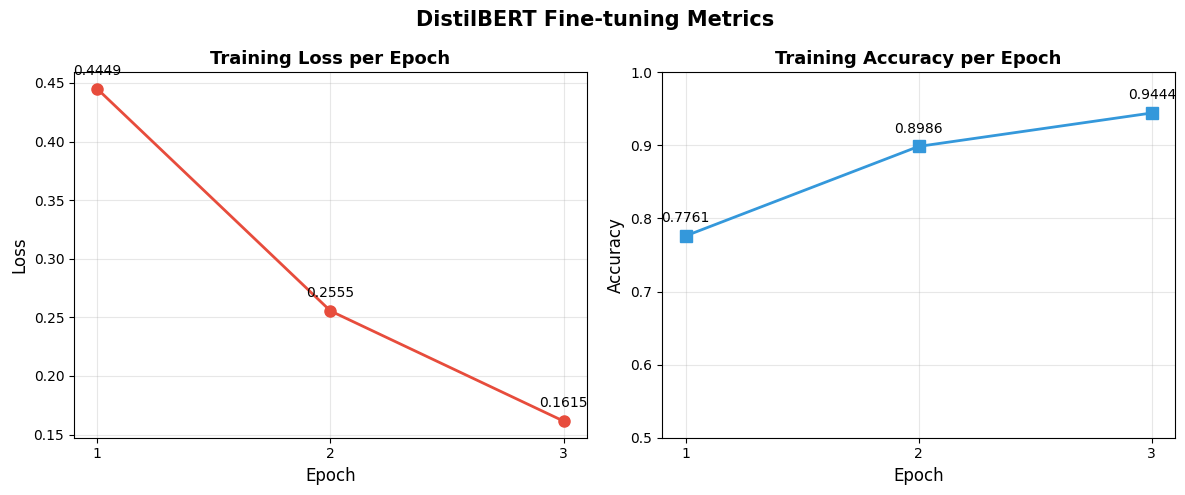

✓ Diagram saved: training_curves.png


In [16]:
# Cell 14: DIAGRAM 3 - Training Loss & Accuracy Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
axes[0].plot(range(1, epochs+1), train_losses, marker='o', linewidth=2, markersize=8, color='#e74c3c')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss per Epoch', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, epochs+1))
for i, loss in enumerate(train_losses):
    axes[0].annotate(f'{loss:.4f}', (i+1, loss), textcoords="offset points", xytext=(0,10), ha='center')

# Accuracy plot
axes[1].plot(range(1, epochs+1), train_accuracies, marker='s', linewidth=2, markersize=8, color='#3498db')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy per Epoch', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, epochs+1))
axes[1].set_ylim([0.5, 1.0])
for i, acc in enumerate(train_accuracies):
    axes[1].annotate(f'{acc:.4f}', (i+1, acc), textcoords="offset points", xytext=(0,10), ha='center')

plt.suptitle('DistilBERT Fine-tuning Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Diagram saved: training_curves.png")

In [17]:
# Cell 15: Evaluation on test set
def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Load best model
model.load_state_dict(torch.load('best_distilbert_model.pt', weights_only=True))
model.eval()

print("Evaluating on test set...")
y_true, y_pred = evaluate_model(model, test_loader, device)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print("\n" + "="*50)
print("DISTILBERT TEST SET PERFORMANCE")
print("="*50)
print(f"{'Metric':<20} {'Score':<10}")
print("-"*30)
print(f"{'Accuracy':<20} {accuracy:.4f}")
print(f"{'Precision (weighted)':<20} {precision:.4f}")
print(f"{'Recall (weighted)':<20} {recall:.4f}")
print(f"{'F1 Score (weighted)':<20} {f1:.4f}")
print("="*50)

# Store for later comparison
distilbert_metrics = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

Evaluating on test set...

DISTILBERT TEST SET PERFORMANCE
Metric               Score     
------------------------------
Accuracy             0.8705
Precision (weighted) 0.8707
Recall (weighted)    0.8705
F1 Score (weighted)  0.8705


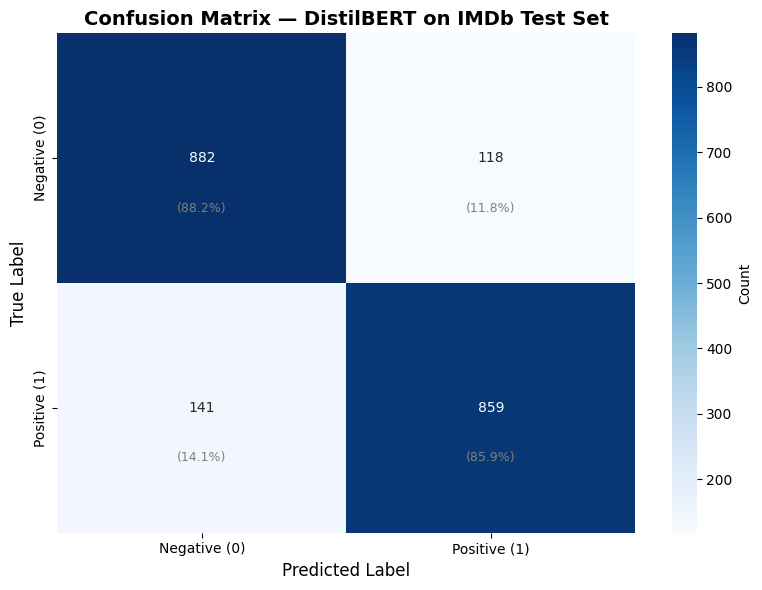

✓ Diagram saved: confusion_matrix.png


In [18]:
# Cell 16: DIAGRAM 4 - Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            ax=ax, cbar_kws={'label': 'Count'})

# Add percentage annotations
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.7, f'({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', color='gray', fontsize=9)

plt.title('Confusion Matrix — DistilBERT on IMDb Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Diagram saved: confusion_matrix.png")

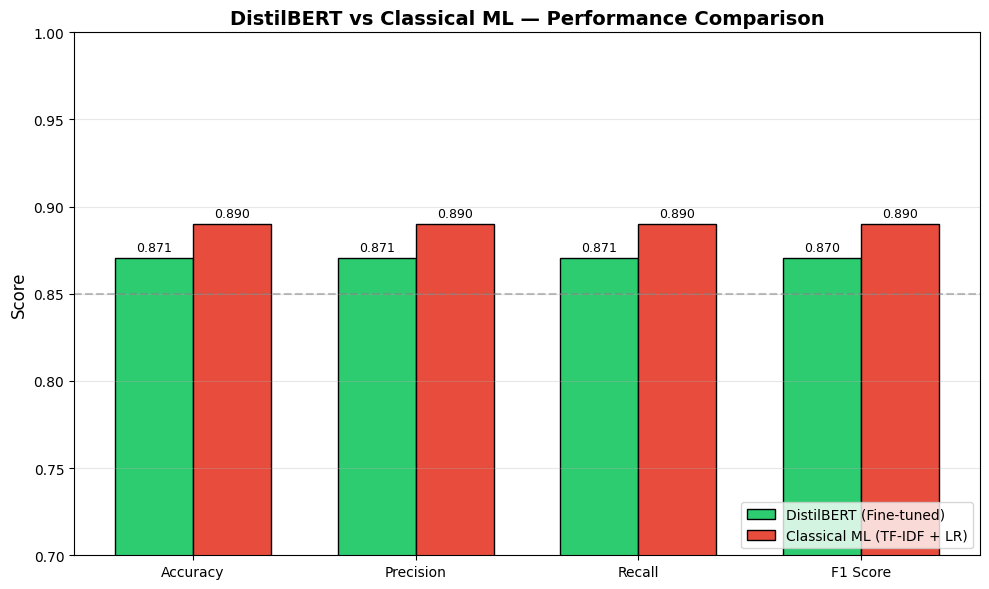

✓ Diagram saved: model_comparison.png

DistilBERT Improvement over Classical ML:
  Accuracy: +-1.95%
  F1 Score: +-1.95%


In [19]:
# Cell 17: DIAGRAM 5 - Metrics Comparison Bar Chart
# Classical ML baseline (TF-IDF + Logistic Regression)
# Update these values with your actual Project 1 scores
classical_metrics = {
    'accuracy': 0.89,
    'precision': 0.89,
    'recall': 0.89,
    'f1': 0.89
}

# Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
distilbert_scores = [distilbert_metrics[m] for m in ['accuracy', 'precision', 'recall', 'f1']]
classical_scores = [classical_metrics[m] for m in ['accuracy', 'precision', 'recall', 'f1']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, distilbert_scores, width, label='DistilBERT (Fine-tuned)', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, classical_scores, width, label='Classical ML (TF-IDF + LR)', color='#e74c3c', edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('DistilBERT vs Classical ML — Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0.7, 1.0)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Diagram saved: model_comparison.png")
print(f"\nDistilBERT Improvement over Classical ML:")
print(f"  Accuracy: +{(distilbert_metrics['accuracy']-classical_metrics['accuracy'])*100:.2f}%")
print(f"  F1 Score: +{(distilbert_metrics['f1']-classical_metrics['f1'])*100:.2f}%")

In [20]:
# Cell 18: Inference demo function
def predict_sentiment(text, model, tokenizer, device):
    """Predict sentiment of a given text"""
    model.eval()

    # Tokenize
    encoding = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(logits, dim=1).item()
        confidence = probs[0][pred].item()

    sentiment = "Positive 😊" if pred == 1 else "Negative 😞"
    return sentiment, confidence

# Test examples
test_reviews = [
    "This movie was absolutely amazing, I loved every second! The acting was superb and the plot kept me on the edge of my seat.",
    "Worst movie I have ever seen. Complete waste of time. The dialogue was terrible and the special effects looked like they were from 1990.",
    "It was okay, nothing special but not terrible either. Some parts were interesting but overall it was just average."
]

print("="*60)
print("SENTIMENT PREDICTION DEMO")
print("="*60)

results = []
for review in test_reviews:
    sentiment, confidence = predict_sentiment(review, model, tokenizer, device)
    results.append((review[:60] + "...", sentiment, confidence))
    print(f"\nReview: {review[:80]}...")
    print(f"Prediction: {sentiment}")
    print(f"Confidence: {confidence:.2%}")
    print("-"*40)

SENTIMENT PREDICTION DEMO

Review: This movie was absolutely amazing, I loved every second! The acting was superb a...
Prediction: Positive 😊
Confidence: 99.50%
----------------------------------------

Review: Worst movie I have ever seen. Complete waste of time. The dialogue was terrible ...
Prediction: Negative 😞
Confidence: 99.69%
----------------------------------------

Review: It was okay, nothing special but not terrible either. Some parts were interestin...
Prediction: Negative 😞
Confidence: 93.03%
----------------------------------------


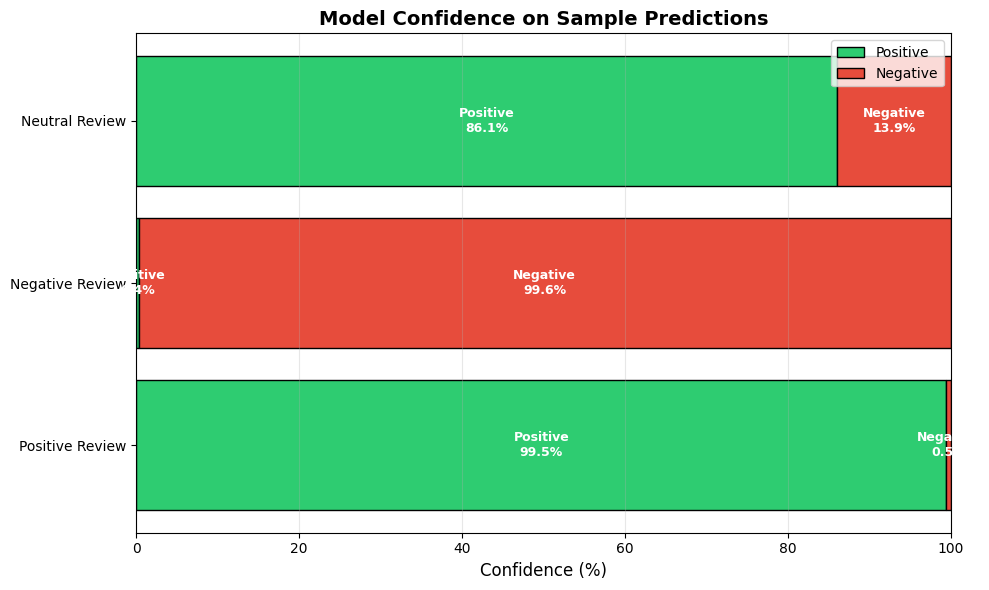

✓ Diagram saved: sample_predictions.png


In [23]:
# Cell 19: DIAGRAM 6 - Sample Prediction Visualization
# Re-run predictions to get confidence scores for both classes
def get_confidence_scores(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(text, max_length=128, padding="max_length", truncation=True, return_tensors="pt")
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        return probs[0].cpu().numpy()

test_texts = [
    "This movie was absolutely amazing, I loved every second!",
    "Worst movie I have ever seen. Complete waste of time.",
    "It was okay, nothing special but not terrible either."
]
short_names = ["Positive Review", "Negative Review", "Neutral Review"]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(test_texts))
colors_bar = ['#2ecc71', '#e74c3c', '#f39c12']

for i, (text, name) in enumerate(zip(test_texts, short_names)):
    scores = get_confidence_scores(text, model, tokenizer, device)
    neg_conf = scores[0] * 100
    pos_conf = scores[1] * 100

    # Horizontal stacked bar
    bars = ax.barh(i, pos_conf, left=0, color='#2ecc71', edgecolor='black', linewidth=1, label='Positive' if i==0 else "")
    bars = ax.barh(i, neg_conf, left=pos_conf, color='#e74c3c', edgecolor='black', linewidth=1, label='Negative' if i==0 else "")

    # Add text annotations
    ax.text(pos_conf/2, i, f'Positive\n{pos_conf:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    ax.text(pos_conf + neg_conf/2, i, f'Negative\n{neg_conf:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(short_names)
ax.set_xlabel('Confidence (%)', fontsize=12)
ax.set_title('Model Confidence on Sample Predictions', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Diagram saved: sample_predictions.png")

# Cell 20: Save all outputs summary (Text Cell)
"""
# Project Output Summary

## 📊 Generated Diagrams (6 files)
All diagrams are saved as high-resolution PNG files suitable for GitHub showcase.

| # | Diagram Name | Filename | Description |
|---|--------------|----------|-------------|
| 1 | Class Distribution | `class_distribution.png` | Bar chart showing balanced sentiment classes (10k samples) |
| 2 | DistilBERT Architecture | `distilbert_pipeline.png` | Pipeline diagram of the model architecture |
| 3 | Training Metrics | `training_curves.png` | Loss & accuracy curves across 3 epochs |
| 4 | Confusion Matrix | `confusion_matrix.png` | Heatmap of predictions vs actual labels |
| 5 | Model Comparison | `model_comparison.png` | DistilBERT vs Classical ML (4 metrics) |
| 6 | Sample Predictions | `sample_predictions.png` | Confidence scores for 3 test reviews |

## 📈 Final Model Performance
